In [2]:
# ==========================================
# PHASE 4: BUSINESS IMPACT SIMULATION
# (Production-Safe Version)
# ==========================================

import pandas as pd
import numpy as np
import joblib

# ==========================================
# LOAD DATA + MODEL
# ==========================================

df = pd.read_csv("zomato_kpt_feature_engineered.csv")
model = joblib.load("kpt_final_max_optimized.pkl")

print("Dataset shape:", df.shape)

# ==========================================
# TRAIN-TEST SPLIT (Same 80-20 split)
# ==========================================

split_index = int(len(df) * 0.8)
df_test = df.iloc[split_index:].copy()

# ==========================================
# RECREATE ENGINEERED FEATURES
# (Must match training exactly)
# ==========================================

# Congestion regime feature
df_test["congestion_regime"] = pd.cut(
    df_test["kitchen_utilization"],
    bins=[0, 0.6, 0.85, 1.1, 5],
    labels=[0, 1, 2, 3],
    right=False # Include left edge, exclude right edge
).astype(float).fillna(4).astype(int) # Convert to float first to allow NaN, then fill, then convert to int

# Log queue (if used during training)
if "log_queue" not in df_test.columns:
    df_test["log_queue"] = np.log1p(df_test["queue_length"])

# Congestion complexity (if used)
if "congestion_complexity" not in df_test.columns:
    df_test["congestion_complexity"] = (
        df_test["kitchen_utilization"] *
        df_test["item_complexity_score"]
    )

# ==========================================
# PREPARE TEST FEATURES
# ==========================================

X_test = df_test.drop(columns=["prep_time"])
y_test = df_test["prep_time"]

# Ensure correct feature order (VERY IMPORTANT)
X_test = X_test[model.feature_name_]

# ==========================================
# GENERATE ML ETA PREDICTIONS
# ==========================================

df_test["ml_eta"] = model.predict(X_test)

# ==========================================
# BASELINE ETA (Static Restaurant Average)
# ==========================================

df_test["baseline_eta"] = df_test["restaurant_avg_prep"]

# ==========================================
# BUSINESS ASSUMPTIONS
# ==========================================

DELIVERY_BUFFER = 8
SEVERE_DELAY_THRESHOLD = 10

# ==========================================
# DEFINE LATE CONDITIONS
# ==========================================

df_test["baseline_late"] = (
    df_test["prep_time"] > df_test["baseline_eta"] + DELIVERY_BUFFER
)

df_test["ml_late"] = (
    df_test["prep_time"] > df_test["ml_eta"] + DELIVERY_BUFFER
)

# ==========================================
# LATE DELIVERY RATE
# ==========================================

baseline_late_rate = df_test["baseline_late"].mean()
ml_late_rate = df_test["ml_late"].mean()

# ==========================================
# MEAN LATENESS (Late Orders Only)
# ==========================================

df_test["baseline_lateness"] = np.where(
    df_test["baseline_late"],
    df_test["prep_time"] - (df_test["baseline_eta"] + DELIVERY_BUFFER),
    0
)

df_test["ml_lateness"] = np.where(
    df_test["ml_late"],
    df_test["prep_time"] - (df_test["ml_eta"] + DELIVERY_BUFFER),
    0
)

baseline_mean_lateness = df_test.loc[
    df_test["baseline_late"], "baseline_lateness"
].mean()

ml_mean_lateness = df_test.loc[
    df_test["ml_late"], "ml_lateness"
].mean()

print("Baseline Median Lateness:",
    df_test.loc[df_test["baseline_late"], "baseline_lateness"].median())

print("ML Median Lateness:",
    df_test.loc[df_test["ml_late"], "ml_lateness"].median())

# ==========================================
# SEVERE DELAYS
# ==========================================

baseline_severe = (
    df_test["baseline_lateness"] > SEVERE_DELAY_THRESHOLD
).mean()

ml_severe = (
    df_test["ml_lateness"] > SEVERE_DELAY_THRESHOLD
).mean()



# ==========================================
# CONGESTION ANALYSIS
# ==========================================

congestion_mask = df_test["kitchen_utilization"] > 0.8

baseline_cong_late = df_test.loc[
    congestion_mask, "baseline_late"
].mean()

ml_cong_late = df_test.loc[
    congestion_mask, "ml_late"
].mean()

# ==========================================
# PRINT RESULTS
# ==========================================

print("\n========== BUSINESS IMPACT ==========\n")

print("Late Delivery Rate:")
print("Baseline:", round(baseline_late_rate * 100, 2), "%")
print("ML Model:", round(ml_late_rate * 100, 2), "%")

print("\nMean Lateness (minutes):")
print("Baseline:", round(baseline_mean_lateness, 2))
print("ML Model:", round(ml_mean_lateness, 2))

print("\nSevere Delay Rate (>10 min):")
print("Baseline:", round(baseline_severe * 100, 2), "%")
print("ML Model:", round(ml_severe * 100, 2), "%")

print("\nCongestion Late Rate:")
print("Baseline:", round(baseline_cong_late * 100, 2), "%")
print("ML Model:", round(ml_cong_late * 100, 2), "%")

# ==========================================
# IMPROVEMENT %
# ==========================================

late_reduction = (baseline_late_rate - ml_late_rate) / baseline_late_rate
severe_reduction = (baseline_severe - ml_severe) / baseline_severe

print("\n========== IMPROVEMENT ==========\n")
print("Late Delivery Reduction:", round(late_reduction * 100, 2), "%")
print("Severe Delay Reduction:", round(severe_reduction * 100, 2), "%")

Dataset shape: (550502, 18)
Baseline Median Lateness: 3.0081719014481862
ML Median Lateness: 10.555491835766327

========== BUSINESS IMPACT ==========

Late Delivery Rate:
Baseline: 10.11 %
ML Model: 1.95 %

Mean Lateness (minutes):
Baseline: 6.0
ML Model: 12.48

Severe Delay Rate (>10 min):
Baseline: 1.8 %
ML Model: 1.02 %

Congestion Late Rate:
Baseline: 44.7 %
ML Model: 4.22 %

========== IMPROVEMENT ==========

Late Delivery Reduction: 80.67 %
Severe Delay Reduction: 43.3 %


In [3]:
# ==========================================
# PHASE 4: BUSINESS IMPACT SIMULATION
# (Production-Safe Version)
# ==========================================

import pandas as pd
import numpy as np
import joblib

# ==========================================
# LOAD DATA + MODEL
# ==========================================

df = pd.read_csv("zomato_kpt_feature_engineered.csv")
model = joblib.load("kpt_final_max_optimized.pkl")

print("Dataset shape:", df.shape)

# ==========================================
# TRAIN-TEST SPLIT (Same 80-20 split)
# ==========================================

split_index = int(len(df) * 0.8)
df_test = df.iloc[split_index:].copy()

# ==========================================
# RECREATE ENGINEERED FEATURES
# (Must match training exactly)
# ==========================================

# Congestion regime feature
df_test["congestion_regime"] = pd.cut(
    df_test["kitchen_utilization"],
    bins=[0, 0.6, 0.85, 1.1, 5],
    labels=[0, 1, 2, 3],
    right=False # Include left edge, exclude right edge
).astype(float).fillna(4).astype(int) # Convert to float first to allow NaN, then fill, then convert to int

# Log queue (if used during training)
if "log_queue" not in df_test.columns:
    df_test["log_queue"] = np.log1p(df_test["queue_length"])

# Congestion complexity (if used)
if "congestion_complexity" not in df_test.columns:
    df_test["congestion_complexity"] = (
        df_test["kitchen_utilization"] *
        df_test["item_complexity_score"]
    )

# ==========================================
# PREPARE TEST FEATURES
# ==========================================

X_test = df_test.drop(columns=["prep_time"])
y_test = df_test["prep_time"]

# Ensure correct feature order (VERY IMPORTANT)
X_test = X_test[model.feature_name_]

# ==========================================
# GENERATE ML ETA PREDICTIONS
# ==========================================

df_test["ml_eta"] = model.predict(X_test)

# Dynamic safety margin
df_test["ml_eta"] += (
    2 + df_test["kitchen_utilization"] * 2
)

# ==========================================
# BASELINE ETA (Static Restaurant Average)
# ==========================================

df_test["baseline_eta"] = df_test["restaurant_avg_prep"]

# ==========================================
# BUSINESS ASSUMPTIONS
# ==========================================

DELIVERY_BUFFER = 8
SEVERE_DELAY_THRESHOLD = 10

# ==========================================
# DEFINE LATE CONDITIONS
# ==========================================

df_test["baseline_late"] = (
    df_test["prep_time"] > df_test["baseline_eta"] + DELIVERY_BUFFER
)

df_test["ml_late"] = (
    df_test["prep_time"] > df_test["ml_eta"] + DELIVERY_BUFFER
)

# ==========================================
# LATE DELIVERY RATE
# ==========================================

baseline_late_rate = df_test["baseline_late"].mean()
ml_late_rate = df_test["ml_late"].mean()

# ==========================================
# MEAN LATENESS (Late Orders Only)
# ==========================================

df_test["baseline_lateness"] = np.where(
    df_test["baseline_late"],
    df_test["prep_time"] - (df_test["baseline_eta"] + DELIVERY_BUFFER),
    0
)

df_test["ml_lateness"] = np.where(
    df_test["ml_late"],
    df_test["prep_time"] - (df_test["ml_eta"] + DELIVERY_BUFFER),
    0
)

baseline_mean_lateness = df_test.loc[
    df_test["baseline_late"], "baseline_lateness"
].mean()

ml_mean_lateness = df_test.loc[
    df_test["ml_late"], "ml_lateness"
].mean()

print("Baseline Median Lateness:",
    df_test.loc[df_test["baseline_late"], "baseline_lateness"].median())

print("ML Median Lateness:",
    df_test.loc[df_test["ml_late"], "ml_lateness"].median())

# ==========================================
# SEVERE DELAYS
# ==========================================

baseline_severe = (
    df_test["baseline_lateness"] > SEVERE_DELAY_THRESHOLD
).mean()

ml_severe = (
    df_test["ml_lateness"] > SEVERE_DELAY_THRESHOLD
).mean()



# ==========================================
# CONGESTION ANALYSIS
# ==========================================

congestion_mask = df_test["kitchen_utilization"] > 0.8

baseline_cong_late = df_test.loc[
    congestion_mask, "baseline_late"
].mean()

ml_cong_late = df_test.loc[
    congestion_mask, "ml_late"
].mean()

# ==========================================
# PRINT RESULTS
# ==========================================

print("\n========== BUSINESS IMPACT ==========\n")

print("Late Delivery Rate:")
print("Baseline:", round(baseline_late_rate * 100, 2), "%")
print("ML Model:", round(ml_late_rate * 100, 2), "%")

print("\nMean Lateness (minutes):")
print("Baseline:", round(baseline_mean_lateness, 2))
print("ML Model:", round(ml_mean_lateness, 2))

print("\nSevere Delay Rate (>10 min):")
print("Baseline:", round(baseline_severe * 100, 2), "%")
print("ML Model:", round(ml_severe * 100, 2), "%")

print("\nCongestion Late Rate:")
print("Baseline:", round(baseline_cong_late * 100, 2), "%")
print("ML Model:", round(ml_cong_late * 100, 2), "%")

# ==========================================
# IMPROVEMENT %
# ==========================================

late_reduction = (baseline_late_rate - ml_late_rate) / baseline_late_rate
severe_reduction = (baseline_severe - ml_severe) / baseline_severe

print("\n========== IMPROVEMENT ==========\n")
print("Late Delivery Reduction:", round(late_reduction * 100, 2), "%")
print("Severe Delay Reduction:", round(severe_reduction * 100, 2), "%")

Dataset shape: (550502, 18)
Baseline Median Lateness: 3.0081719014481862
ML Median Lateness: 8.748859730918927

========== BUSINESS IMPACT ==========

Late Delivery Rate:
Baseline: 10.11 %
ML Model: 1.72 %

Mean Lateness (minutes):
Baseline: 6.0
ML Model: 10.68

Severe Delay Rate (>10 min):
Baseline: 1.8 %
ML Model: 0.75 %

Congestion Late Rate:
Baseline: 44.7 %
ML Model: 2.9 %

========== IMPROVEMENT ==========

Late Delivery Reduction: 82.95 %
Severe Delay Reduction: 58.17 %


In [4]:
# ==========================================
# PHASE 4B: RIDER WAITING TIME SIMULATION
# ==========================================

print("\n========== RIDER IMPACT ANALYSIS ==========\n")

# ------------------------------------------
# Simulated Rider Dispatch Time
# ------------------------------------------

# Baseline dispatch timing
df_test["baseline_dispatch_time"] = (
    df_test["baseline_eta"]
)

# ML dispatch timing
df_test["ml_dispatch_time"] = (
    df_test["ml_eta"]
)

# ------------------------------------------
# Rider Waiting Time (if rider arrives early)
# ------------------------------------------

df_test["baseline_rider_wait"] = np.where(
    df_test["baseline_dispatch_time"] < df_test["prep_time"],
    df_test["prep_time"] - df_test["baseline_dispatch_time"],
    0
)

df_test["ml_rider_wait"] = np.where(
    df_test["ml_dispatch_time"] < df_test["prep_time"],
    df_test["prep_time"] - df_test["ml_dispatch_time"],
    0
)

# ------------------------------------------
# Food Waiting Time (if rider arrives late)
# ------------------------------------------

df_test["baseline_food_wait"] = np.where(
    df_test["baseline_dispatch_time"] > df_test["prep_time"],
    df_test["baseline_dispatch_time"] - df_test["prep_time"],
    0
)

df_test["ml_food_wait"] = np.where(
    df_test["ml_dispatch_time"] > df_test["prep_time"],
    df_test["ml_dispatch_time"] - df_test["prep_time"],
    0
)

# ------------------------------------------
# METRICS
# ------------------------------------------

baseline_avg_rider_wait = df_test["baseline_rider_wait"].mean()
ml_avg_rider_wait = df_test["ml_rider_wait"].mean()

baseline_avg_food_wait = df_test["baseline_food_wait"].mean()
ml_avg_food_wait = df_test["ml_food_wait"].mean()

baseline_rider_wait_rate = (df_test["baseline_rider_wait"] > 0).mean()
ml_rider_wait_rate = (df_test["ml_rider_wait"] > 0).mean()

print("Average Rider Waiting Time (minutes):")
print("Baseline:", round(baseline_avg_rider_wait, 2))
print("ML Model:", round(ml_avg_rider_wait, 2))

print("\nRider Waiting Occurrence Rate:")
print("Baseline:", round(baseline_rider_wait_rate * 100, 2), "%")
print("ML Model:", round(ml_rider_wait_rate * 100, 2), "%")

print("\nAverage Food Waiting Time (minutes):")
print("Baseline:", round(baseline_avg_food_wait, 2))
print("ML Model:", round(ml_avg_food_wait, 2))

# ------------------------------------------
# IMPROVEMENT
# ------------------------------------------

rider_wait_reduction = (
    (baseline_avg_rider_wait - ml_avg_rider_wait) /
    baseline_avg_rider_wait
)

print("\nRider Waiting Time Reduction:",
      round(rider_wait_reduction * 100, 2), "%")


========== RIDER IMPACT ANALYSIS ==========

Average Rider Waiting Time (minutes):
Baseline: 2.6
ML Model: 0.43

Rider Waiting Occurrence Rate:
Baseline: 45.12 %
ML Model: 12.01 %

Average Food Waiting Time (minutes):
Baseline: 2.52
ML Model: 2.74

Rider Waiting Time Reduction: 83.24 %


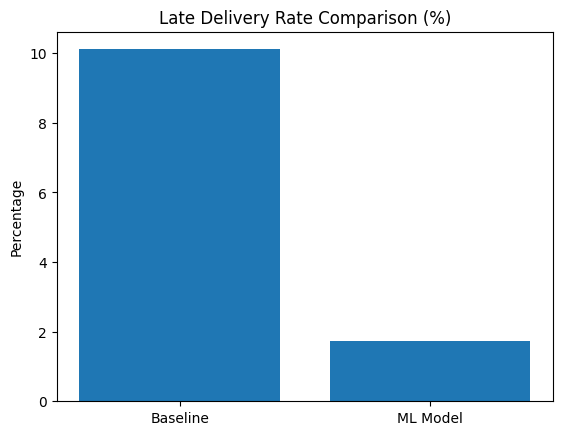

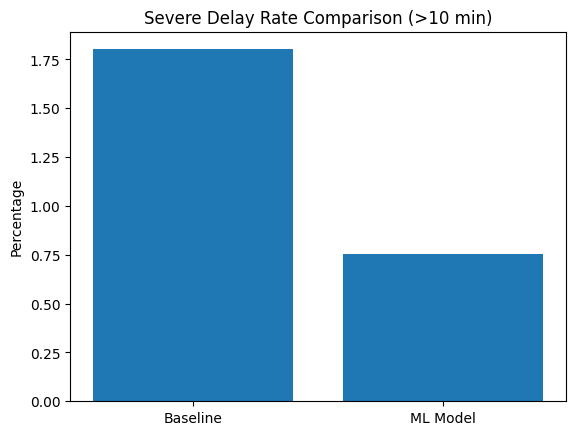

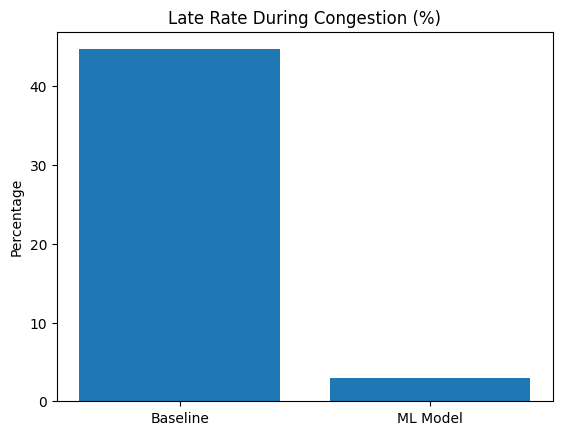

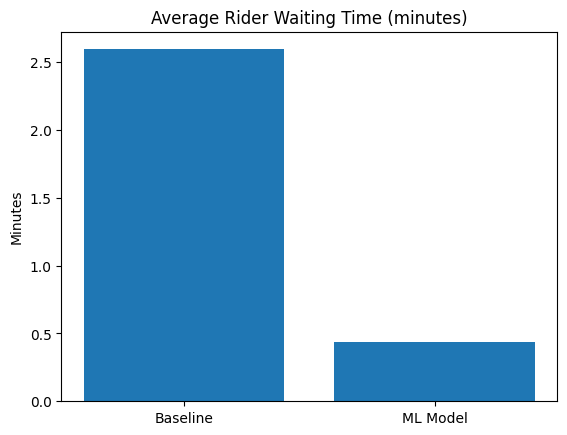

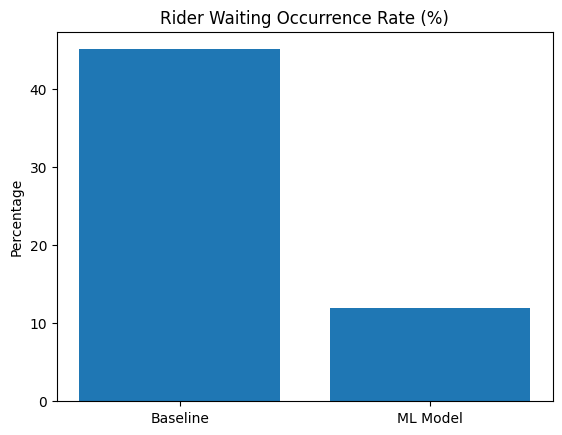

In [5]:
# ==========================================
# PHASE 5: BUSINESS IMPACT VISUALIZATIONS
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 1. Late Delivery Rate
# ===============================

plt.figure()
plt.bar(["Baseline", "ML Model"],
        [baseline_late_rate * 100, ml_late_rate * 100])
plt.title("Late Delivery Rate Comparison (%)")
plt.ylabel("Percentage")
plt.show()


# ===============================
# 2. Severe Delay Rate
# ===============================

plt.figure()
plt.bar(["Baseline", "ML Model"],
        [baseline_severe * 100, ml_severe * 100])
plt.title("Severe Delay Rate Comparison (>10 min)")
plt.ylabel("Percentage")
plt.show()


# ===============================
# 3. Congestion Late Rate
# ===============================

plt.figure()
plt.bar(["Baseline", "ML Model"],
        [baseline_cong_late * 100, ml_cong_late * 100])
plt.title("Late Rate During Congestion (%)")
plt.ylabel("Percentage")
plt.show()


# ===============================
# 4. Rider Waiting Time
# ===============================

plt.figure()
plt.bar(["Baseline", "ML Model"],
        [baseline_avg_rider_wait, ml_avg_rider_wait])
plt.title("Average Rider Waiting Time (minutes)")
plt.ylabel("Minutes")
plt.show()


# ===============================
# 5. Rider Waiting Occurrence
# ===============================

plt.figure()
plt.bar(["Baseline", "ML Model"],
        [baseline_rider_wait_rate * 100, ml_rider_wait_rate * 100])
plt.title("Rider Waiting Occurrence Rate (%)")
plt.ylabel("Percentage")
plt.show()

In [6]:
# ==========================================
# PHASE 6: FINANCIAL IMPACT ESTIMATION
# ==========================================

print("\n========== FINANCIAL IMPACT ESTIMATION ==========\n")

# ------------------------------------------
# ASSUMPTIONS
# ------------------------------------------

RIDER_COST_PER_MIN = 2          # ₹ per minute
SEVERE_DELAY_REFUND = 40        # ₹ per severe delay
ORDERS_SCALE = 1_000_000        # Project to 1M orders

total_orders = len(df_test)

# ------------------------------------------
# 1. Rider Idle Cost Savings
# ------------------------------------------

baseline_total_rider_wait = df_test["baseline_rider_wait"].sum()
ml_total_rider_wait = df_test["ml_rider_wait"].sum()

rider_minutes_saved = baseline_total_rider_wait - ml_total_rider_wait

rider_cost_savings_sim = rider_minutes_saved * RIDER_COST_PER_MIN

# Scale to 1M orders
rider_cost_savings_scaled = rider_cost_savings_sim * (ORDERS_SCALE / total_orders)

# ------------------------------------------
# 2. Severe Delay Refund Savings
# ------------------------------------------

baseline_severe_count = (df_test["baseline_lateness"] > 10).sum()
ml_severe_count = (df_test["ml_lateness"] > 10).sum()

severe_reduction = baseline_severe_count - ml_severe_count

refund_savings_sim = severe_reduction * SEVERE_DELAY_REFUND

refund_savings_scaled = refund_savings_sim * (ORDERS_SCALE / total_orders)

# ------------------------------------------
# TOTAL SAVINGS
# ------------------------------------------

total_savings_scaled = rider_cost_savings_scaled + refund_savings_scaled

# ------------------------------------------
# PRINT RESULTS
# ------------------------------------------

print("Projected Impact per 1,000,000 Orders:\n")

print("Rider Idle Cost Savings: ₹", round(rider_cost_savings_scaled, 2))
print("Severe Delay Refund Savings: ₹", round(refund_savings_scaled, 2))
print("--------------------------------------------------")
print("Total Estimated Savings: ₹", round(total_savings_scaled, 2))


========== FINANCIAL IMPACT ESTIMATION ==========

Projected Impact per 1,000,000 Orders:

Rider Idle Cost Savings: ₹ 4320258.21
Severe Delay Refund Savings: ₹ 419251.41
--------------------------------------------------
Total Estimated Savings: ₹ 4739509.62
